In [57]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [58]:
df.shape
df.isna().sum()
df['Attrition'].value_counts()

# Overall attrition rate
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")

Overall attrition rate: 16.1%


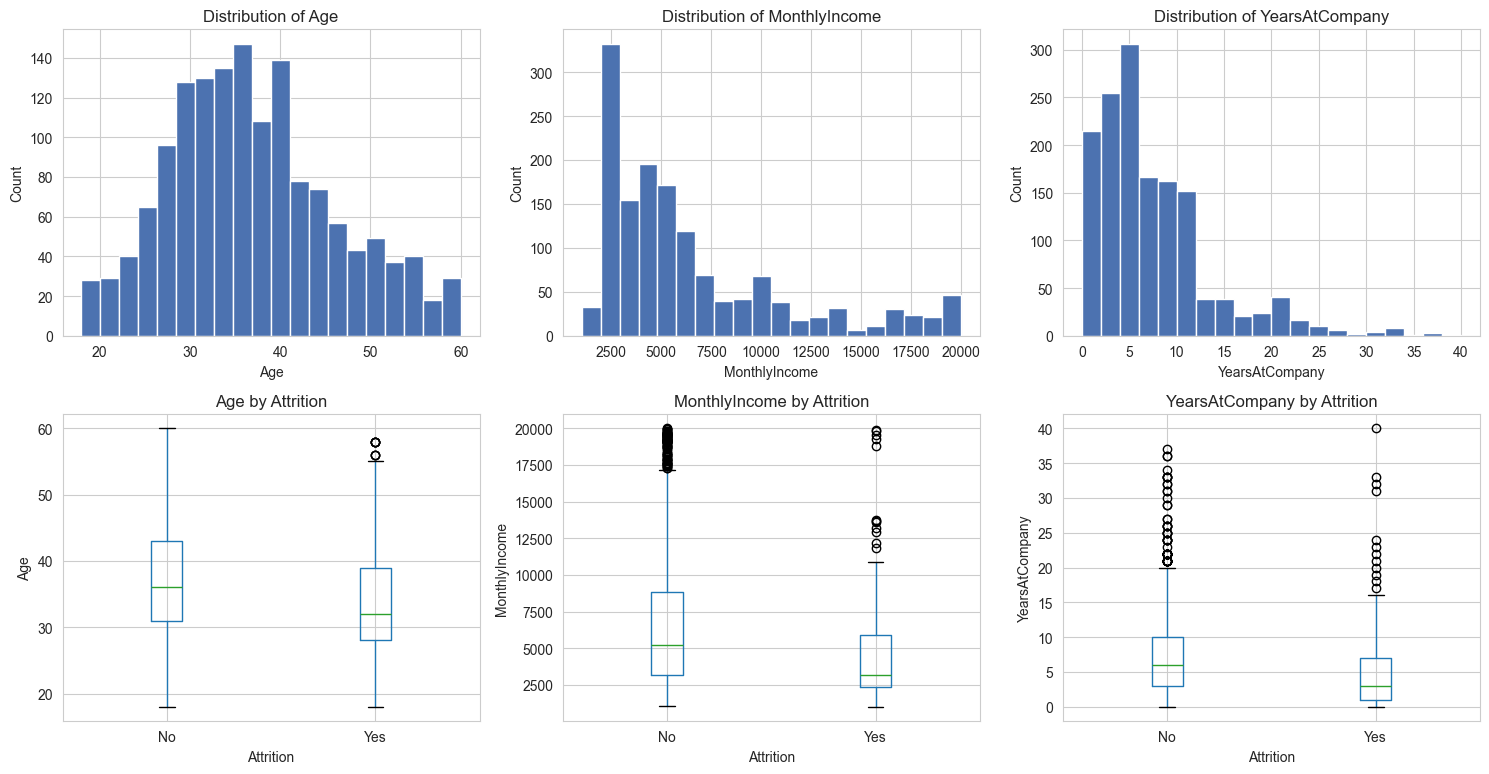

                 Age        MonthlyIncome         YearsAtCompany       
                mean median          mean  median           mean median
Attrition                                                              
No         37.561233   36.0   6832.739659  5204.0       7.369019    6.0
Yes        33.607595   32.0   4787.092827  3202.0       5.130802    3.0


In [59]:
numeric_vars = ['Age', 'MonthlyIncome', 'YearsAtCompany']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(numeric_vars):
    axes[0, i].hist(df[var], bins=20, color='#4C72B0', edgecolor='white')
    axes[0, i].set_title(f'Distribution of {var}')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Count')

    df.boxplot(column=var, by='Attrition', ax=axes[1, i])
    axes[1, i].set_title(f'{var} by Attrition')
    axes[1, i].set_xlabel('Attrition')
    axes[1, i].set_ylabel(var)

plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('Attrition')[numeric_vars].agg(['mean', 'median']))


Attrition rate by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

Attrition rate by JobRole:
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

Attrition rate by MaritalStatus:
MaritalStatus
Single      25.531915
Married     12.481426
Divorced    10.091743
Name: Attrition, dtype: float64


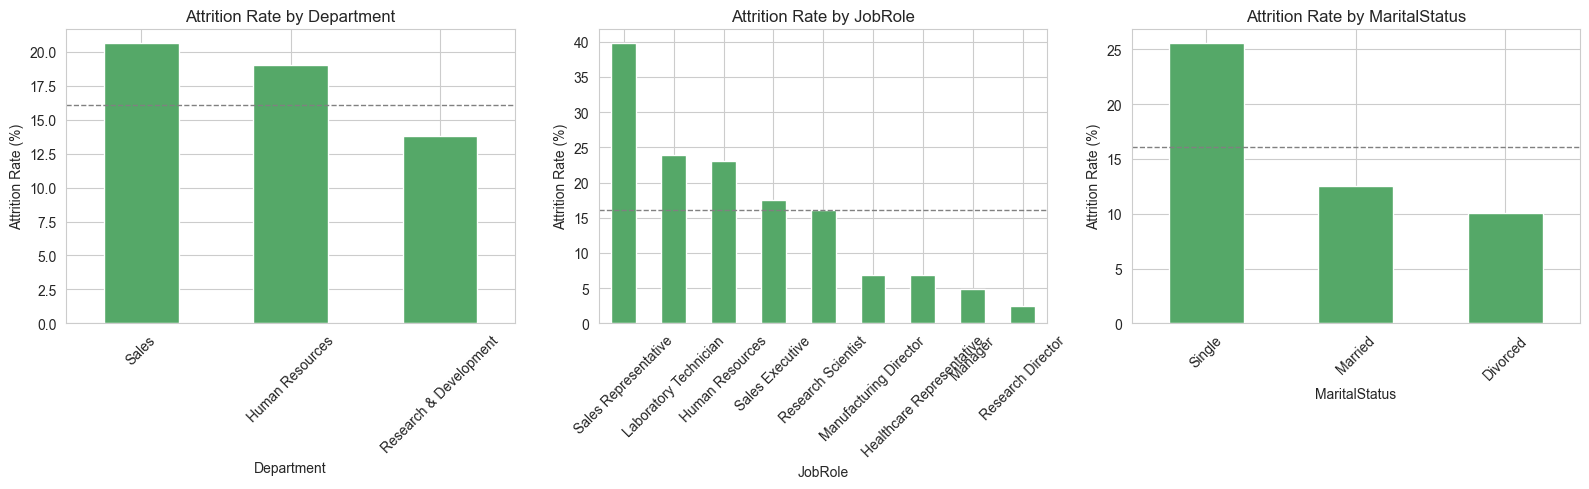

In [60]:
categorical_vars = ['Department', 'JobRole', 'MaritalStatus']

for var in categorical_vars:
    rates = df.groupby(var)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    print(f"\nAttrition rate by {var}:")
    print(rates)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(categorical_vars):
    rates = df.groupby(var)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    rates.plot(kind='bar', ax=axes[i], color='#55A868')
    axes[i].set_title(f'Attrition Rate by {var}')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].axhline(y=16.1, color='gray', linestyle='--', linewidth=1)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [61]:
# Checking whether Sales / Single-Married attrition gaps are explained by OverTime or Age
overtime_by_dept = df.groupby('Department')['OverTime'].apply(lambda x: (x == 'Yes').mean() * 100)
print("OverTime rate by Department (%):")
print(overtime_by_dept)

age_by_dept = df.groupby('Department')['Age'].mean()
print("\nAverage Age by Department:")
print(age_by_dept)

age_by_marital = df.groupby('MaritalStatus')['Age'].mean()
print("\nAverage Age by Marital Status:")
print(age_by_marital)

overtime_by_marital = df.groupby('MaritalStatus')['OverTime'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nOverTime rate by Marital Status (%):")
print(overtime_by_marital)

OverTime rate by Department (%):
Department
Human Resources           26.984127
Research & Development    28.199792
Sales                     28.699552
Name: OverTime, dtype: float64

Average Age by Department:
Department
Human Resources           37.809524
Research & Development    37.042664
Sales                     36.542601
Name: Age, dtype: float64

Average Age by Marital Status:
MaritalStatus
Divorced    37.489297
Married     37.757801
Single      35.336170
Name: Age, dtype: float64

OverTime rate by Marital Status (%):
MaritalStatus
Divorced    30.275229
Married     27.637444
Single      27.872340
Name: OverTime, dtype: float64


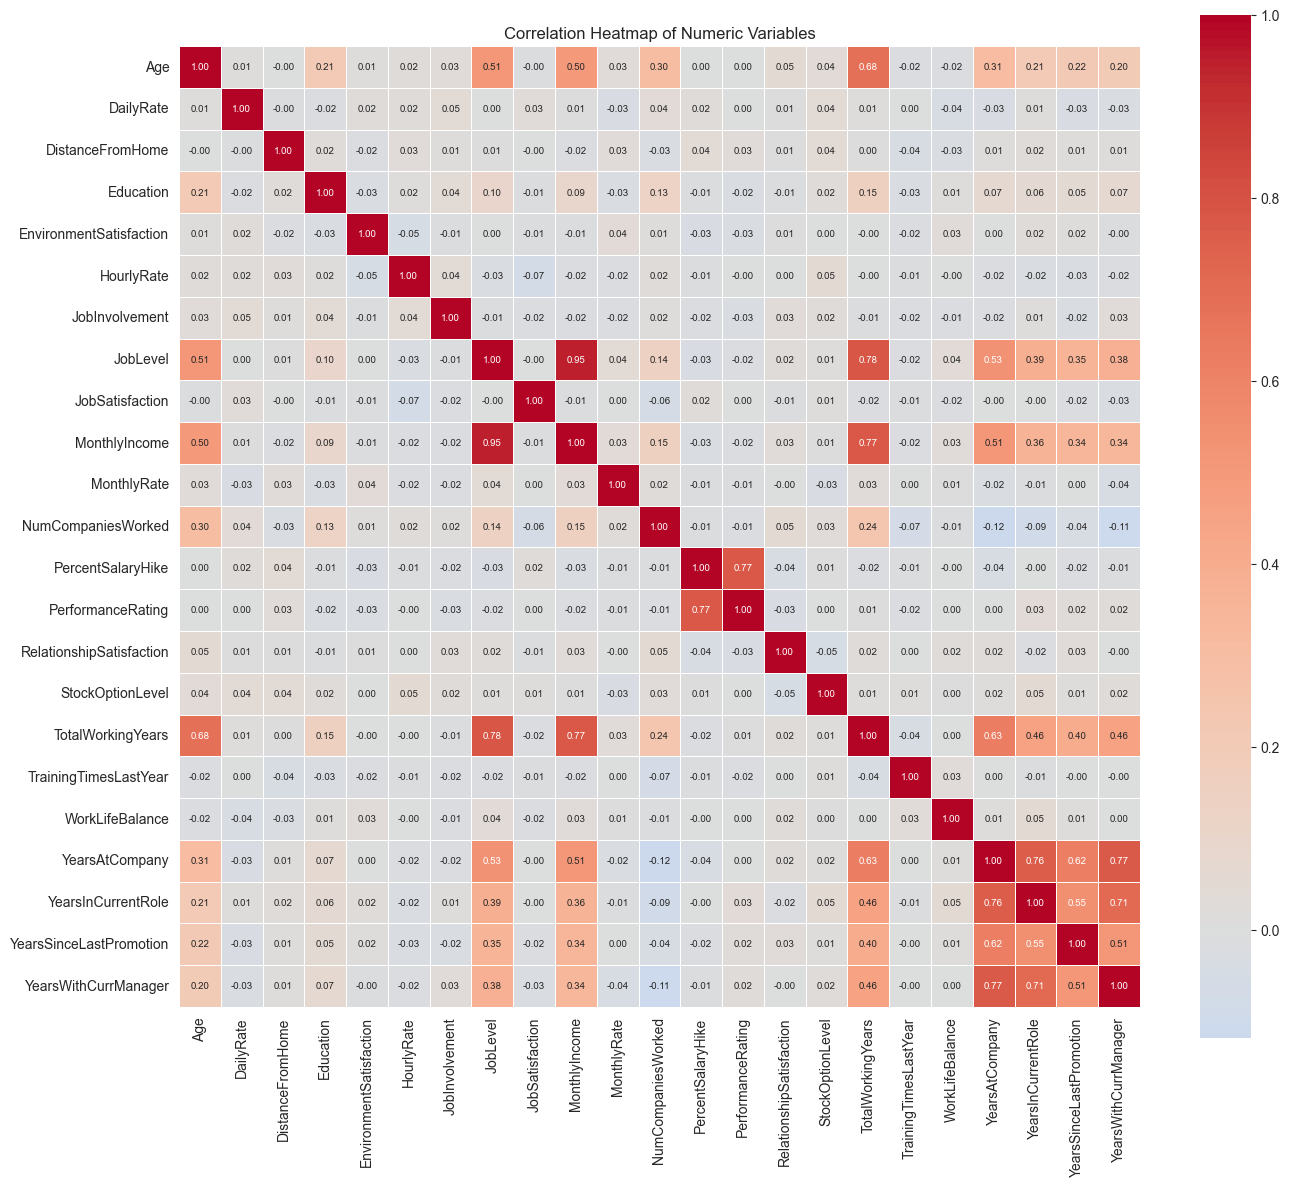

In [62]:
#corellation heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours'], errors='ignore'
)

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

**H1 Overtime & Income**


Attrition rate by OverTime:
OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


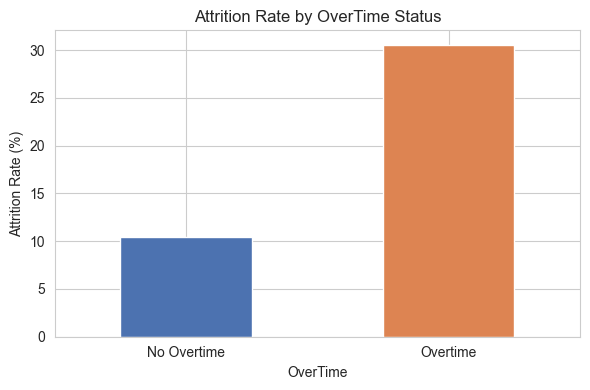

In [63]:
# Attrition rate by OverTime
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nAttrition rate by OverTime:")
print(overtime_attrition)

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
overtime_attrition.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by OverTime Status')
ax.set_xticklabels(['No Overtime', 'Overtime'], rotation=0)
plt.tight_layout()
plt.show()

OverTime  IncomeBand
No        Low           15.580737
          Medium         7.428571
          High           8.262108
Yes       Low           53.284672
          Medium        22.142857
          High          16.546763
Name: Attrition, dtype: float64


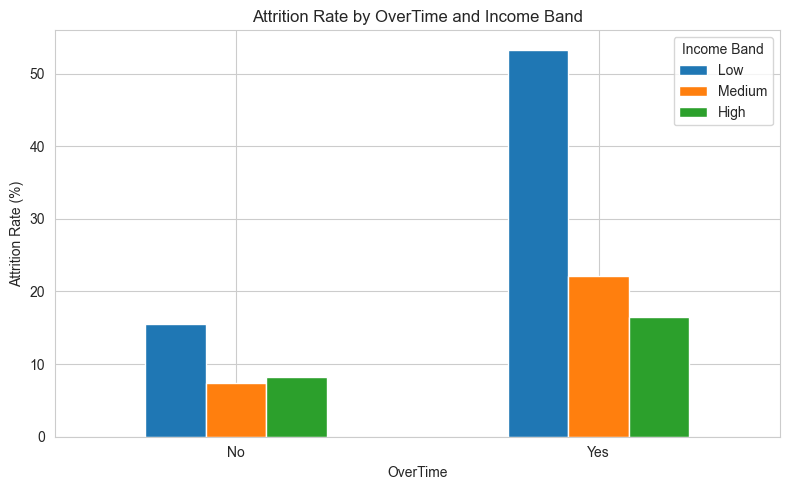

In [64]:
df['IncomeBand'] = pd.qcut(df['MonthlyIncome'], q=3, labels=['Low', 'Medium', 'High'])

combined = df.groupby(['OverTime', 'IncomeBand'])['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print(combined)

combined_df = combined.unstack()
combined_df.plot(kind='bar', figsize=(8, 5))
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by OverTime and Income Band')
plt.xticks(rotation=0)
plt.legend(title='Income Band')
plt.tight_layout()
plt.show()

**H1:** Overtime is a strong driver of attrition, but its impact is not uniform it interacts with income. Low-income employees bear the highest cost of overtime (53.3% attrition vs. 15.6% without overtime), while high-income employees are comparatively insulated, though not fully protected (16.5% vs. 8.3%). This suggests pay buffers but doesn't eliminate overtime-driven burnout/attrition.

**H2 Distance from home & Income**

DistanceBand  IncomeBand
Near          Low           22.674419
              Medium         9.493671
              High           8.092486
Medium        Low           26.111111
              Medium         8.670520
              High           8.235294
Far           Low           30.434783
              Medium        16.981132
              High          16.326531
Name: Attrition, dtype: float64


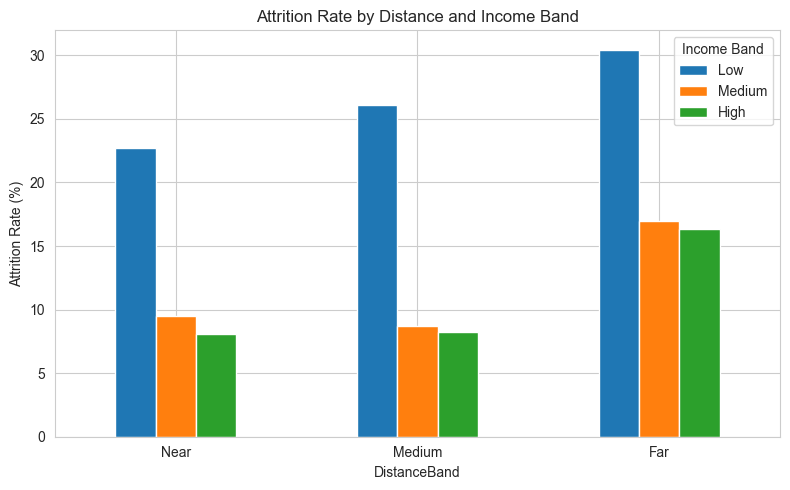

In [65]:
df['DistanceBand'] = pd.qcut(df['DistanceFromHome'], q=3, labels=['Near', 'Medium', 'Far'])

distance_income = df.groupby(['DistanceBand', 'IncomeBand'])['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print(distance_income)

distance_income_df = distance_income.unstack()
distance_income_df.plot(kind='bar', figsize=(8, 5))
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Distance and Income Band')
plt.xticks(rotation=0)
plt.legend(title='Income Band')
plt.tight_layout()
plt.show()

**H2:** Distance from home increases attrition risk by a similar, modest margin (~7-8 percentage points) across all income levels unlike overtime, which showed a strong income-dependent interaction, distance's effect appears largely independent of income. Income itself remains the dominant driver of attrition regardless of commute distance.

**H3: Relative Income vs. Years Since Last Promotion**

In [66]:
level_avg_income = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['IncomeRatioToLevel'] = df['MonthlyIncome'] / level_avg_income
df['RelativeIncomeBand'] = pd.cut(df['IncomeRatioToLevel'],
                                    bins=[0, 0.9, 1.1, float('inf')],
                                    labels=['Below Average', 'Average', 'Above Average'])

relative_income_attrition = df.groupby('RelativeIncomeBand')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition by Relative Income (vs. own JobLevel):")
print(relative_income_attrition)

Attrition by Relative Income (vs. own JobLevel):
RelativeIncomeBand
Below Average    21.497121
Average          13.562387
Above Average    12.626263
Name: Attrition, dtype: float64


In [67]:
df['PromotionGapBand'] = pd.cut(df['YearsSinceLastPromotion'],
                                  bins=[-1, 1, 3, float('inf')],
                                  labels=['Recent (0-1 yr)', 'Moderate (2-3 yr)', 'Long (4+ yr)'])

promotion_attrition = df.groupby('PromotionGapBand')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition by Years Since Last Promotion:")
print(promotion_attrition)

Attrition by Years Since Last Promotion:
PromotionGapBand
Recent (0-1 yr)      16.950959
Moderate (2-3 yr)    17.061611
Long (4+ yr)         13.084112
Name: Attrition, dtype: float64


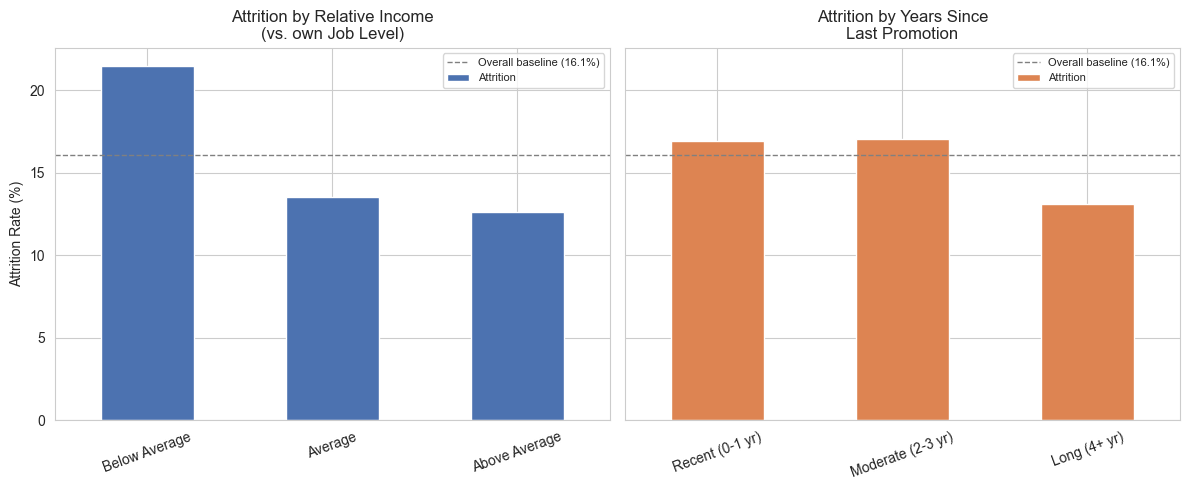

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

relative_income_attrition.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition by Relative Income\n(vs. own Job Level)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

promotion_attrition.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition by Years Since\nLast Promotion')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

for ax in axes:
    ax.axhline(y=16.1, color='gray', linestyle='--', linewidth=1, label='Overall baseline (16.1%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**H3:** Relative income compared to job-level peers is a stronger predictor of attrition (8.9-point spread) than years since last promotion (4.0-point spread, and counterintuitively non-monotonic long-tenured non-promoted staff show *lower* attrition than recently promoted staff). This suggests salary equity within a role matters more to retention than promotion cadence, and that promotion timing alone is a weak or even misleading signal in isolation.

In [69]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18',
             'IncomeBand', 'DistanceBand', 'RelativeIncomeBand', 'PromotionGapBand', 'IncomeRatioToLevel']

df_model = df.drop(columns=drop_cols, errors='ignore')
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)

In [70]:
#Label-encoding for tree models (Random Forest, XGBoost)
from sklearn.preprocessing import LabelEncoder

df_tree = df_model.copy()
cat_cols = df_tree.select_dtypes(include='object').columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_tree[col] = le.fit_transform(df_tree[col])
    label_encoders[col] = le

X_tree = df_tree.drop(columns=['Attrition'])
y_tree = df_tree['Attrition']

C:\Users\HP\AppData\Local\Temp\ipykernel_4568\28522212.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_tree.select_dtypes(include='object').columns.tolist()


In [71]:
#Ordinal & One-hot encoding for Logistic Regression
df_log = df_model.copy()

travel_order = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df_log['BusinessTravel'] = df_log['BusinessTravel'].map(travel_order)

nominal_cols = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_log = pd.get_dummies(df_log, columns=nominal_cols, drop_first=True)

X_log = df_log.drop(columns=['Attrition'])
y_log = df_log['Attrition']

In [72]:
from sklearn.model_selection import train_test_split

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree
)

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

In [73]:
# Overtime x Income interaction term for the Logistic Regression path
X_log_train_int = X_log_train.copy()
X_log_test_int = X_log_test.copy()

X_log_train_int['OverTime_Income_Interaction'] = X_log_train_int['OverTime_Yes'] * X_log_train_int['MonthlyIncome']
X_log_test_int['OverTime_Income_Interaction'] = X_log_test_int['OverTime_Yes'] * X_log_test_int['MonthlyIncome']

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_log_train_scaled = scaler.fit_transform(X_log_train_int)
X_log_test_scaled = scaler.transform(X_log_test_int)

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_log_train_scaled, y_log_train)
log_preds = log_model.predict(X_log_test_scaled)
log_probs = log_model.predict_proba(X_log_test_scaled)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_tree_train, y_tree_train)
rf_preds = rf_model.predict(X_tree_test)
rf_probs = rf_model.predict_proba(X_tree_test)[:, 1]

# XGBoost
scale_pos_weight = (y_tree_train == 0).sum() / (y_tree_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_tree_train, y_tree_train)
xgb_preds = xgb_model.predict(X_tree_test)
xgb_probs = xgb_model.predict_proba(X_tree_test)[:, 1]

for name, preds, probs, y_true in [
    ('Logistic Regression', log_preds, log_probs, y_log_test),
    ('Random Forest', rf_preds, rf_probs, y_tree_test),
    ('XGBoost', xgb_preds, xgb_probs, y_tree_test)
]:
    print(f"\n{name} ")
    print("ROC-AUC:", roc_auc_score(y_true, probs))
    print(classification_report(y_true, preds))


Logistic Regression 
ROC-AUC: 0.8004134723059695
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.37      0.68      0.48        47

    accuracy                           0.76       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.76      0.79       294


Random Forest 
ROC-AUC: 0.7573865104660178
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294


XGBoost 
ROC-AUC: 0.7697476096132311
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.56      0.32      0.41        47

    accuracy                           0.85       

**Model decision:** Logistic Regression selected as the final model: ROC-AUC 0.80, recall 0.68 on the "Left" class, clearly outperforming Random Forest (recall 0.09) and XGBoost (recall 0.32). This is largely due to the explicitly engineered  `OverTime_Income_Interaction` term, which let Logistic Regression capture the H1 interaction effect that the tree models likely limited by this dataset's small size did not learn as reliably on their own.

In [76]:
import pickle

with open('attrition_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

model_columns = X_log_train_int.columns.tolist()
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)